# Transfer Learning USAD: SWaT (51 ch.) -> SIATA Temperatura (1 ch.)

Este notebook orquesta el pipeline de transfer learning por sub-matriz del encoder pre-entrenado USAD (SWaT, 51 sensores) hacia los datos de temperatura de la estación SIATA **68 - Jardín Botánico**.

Estrategia:
1. Sub-matriz de `encoder.linear1` correspondiente al sensor `FIT101` (idx=1).
2. Decoders recortados a 12 salidas (1 canal x 12 timesteps).
3. Fine-tuning sobre split `E` (sólo `flag==0`).
4. ROC sobre `E` (requisito explícito); F1/Accuracy comparativos en E/T/V.
5. Detección de anomalías en `T` y `V`.

Ejecutable en Google Colab montando el repo de GitHub.

## 1. Setup (clonar repo + dependencias)

In [1]:
import os, sys

GITHUB_USER = "ronvas234"              # <-- Cambiar por tu usuario GitHub
REPO_NAME   = "data-science-monograph" # <-- Cambiar por el nombre del repo
BRANCH      = "feature/transfer-learning-plan-c"

REPO_DIR = f"/content/{REPO_NAME}"
USAD_DIR = f"{REPO_DIR}/modelos/usad"
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        !git clone -b {BRANCH} https://github.com/{GITHUB_USER}/{REPO_NAME}.git {REPO_DIR}
    else:
        !cd {REPO_DIR} && git pull
    !pip install -q torch pandas scikit-learn matplotlib seaborn
    os.chdir(USAD_DIR)
# En local el notebook vive en modelos/usad; si el kernel arranco en otro cwd, ajustalo manualmente.

sys.path.insert(0, os.getcwd())
print('cwd =', os.getcwd())

Cloning into '/content/data-science-monograph'...
remote: Enumerating objects: 223, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 223 (delta 16), reused 56 (delta 11), pack-reused 153 (from 1)
Receiving objects: 100% (223/223), 19.08 MiB | 11.41 MiB/s, done.
Resolving deltas: 100% (62/62), done.
cwd = /content/data-science-monograph/modelos/usad


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from utils import get_default_device, to_device, plot_history, ROC, confusion_matrix, histogram

from transfer_learning.tl_config import TLConfig
from transfer_learning.tl_data import build_splits, make_loader
from transfer_learning.tl_model import SubMatrixWeightAdapter, TransferUsadModel
from transfer_learning.tl_trainer import TransferTrainer
from transfer_learning.tl_evaluator import AnomalyScorer, ThresholdSelector, MetricsReporter

cfg = TLConfig()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
device = get_default_device()
print('device =', device)

device = cpu


## 3. Data: cargar 68.csv, normalizar y ventanizar

In [3]:
normalizer, splits = build_splits(cfg.csv_path, cfg.window_size)
for name, (wd, raw) in splits.items():
    print(f'{name}: windows={wd.windows.shape}, positives={int(wd.labels.sum())}')

train_loader = make_loader(splits['E_train'][0].windows, cfg.batch_size, shuffle=True)
val_loader   = make_loader(splits['V'][0].windows,       cfg.batch_size, shuffle=False)
eval_E = make_loader(splits['E_all'][0].windows, cfg.batch_size, shuffle=False)
eval_T = make_loader(splits['T'][0].windows,     cfg.batch_size, shuffle=False)
eval_V = make_loader(splits['V'][0].windows,     cfg.batch_size, shuffle=False)

E_train: windows=(37097, 12), positives=0
E_all: windows=(37391, 12), positives=360
T: windows=(38869, 12), positives=1850
V: windows=(7187, 12), positives=0


## 4. Modelo: construir TransferUsadModel desde sub-matriz

In [4]:
adapter = SubMatrixWeightAdapter(
    checkpoint_path=cfg.checkpoint_path,
    sensor_idx=cfg.sensor_idx,
    n_sensors=cfg.pretrained_n_sensors,
    window_size=cfg.window_size,
)
adapted = adapter.build_state_dict()
assert adapted['encoder']['linear1.weight'].shape == (306, 12)
assert adapted['decoder1']['linear3.weight'].shape == (12, 306)

model = TransferUsadModel(w_size=cfg.w_size, z_size=cfg.z_size)
model.load_adapted(adapted)
model = to_device(model, device)
print(model)

TransferUsadModel(
  (encoder): TransferEncoder(
    (linear1): Linear(in_features=12, out_features=306, bias=True)
    (linear2): Linear(in_features=306, out_features=153, bias=True)
    (linear3): Linear(in_features=153, out_features=120, bias=True)
    (relu): ReLU(inplace=True)
  )
  (decoder1): TransferDecoder(
    (linear1): Linear(in_features=120, out_features=153, bias=True)
    (linear2): Linear(in_features=153, out_features=306, bias=True)
    (linear3): Linear(in_features=306, out_features=12, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )
  (decoder2): TransferDecoder(
    (linear1): Linear(in_features=120, out_features=153, bias=True)
    (linear2): Linear(in_features=153, out_features=306, bias=True)
    (linear3): Linear(in_features=306, out_features=12, bias=True)
    (relu): ReLU(inplace=True)
    (sigmoid): Sigmoid()
  )
)


## 5. Fine-tuning

Epoch [0], val_loss1: 0.0039, val_loss2: 0.0038
Epoch [1], val_loss1: 0.0028, val_loss2: -0.0008
Epoch [2], val_loss1: 0.0034, val_loss2: -0.0021
Epoch [3], val_loss1: 0.0039, val_loss2: -0.0029
Epoch [4], val_loss1: 0.0057, val_loss2: -0.0046
Epoch [5], val_loss1: 0.0088, val_loss2: -0.0074
Epoch [6], val_loss1: 0.0113, val_loss2: -0.0102
Epoch [7], val_loss1: 0.0151, val_loss2: -0.0133
Epoch [8], val_loss1: 0.0147, val_loss2: -0.0132
Epoch [9], val_loss1: 0.0142, val_loss2: -0.0133
Epoch [10], val_loss1: 0.0206, val_loss2: -0.0189
Epoch [11], val_loss1: 0.0133, val_loss2: -0.0125
Epoch [12], val_loss1: 0.0144, val_loss2: -0.0138
Epoch [13], val_loss1: 0.0143, val_loss2: -0.0135
Epoch [14], val_loss1: 0.0157, val_loss2: -0.0149
Epoch [15], val_loss1: 0.0136, val_loss2: -0.0131
Epoch [16], val_loss1: 0.0129, val_loss2: -0.0123
Epoch [17], val_loss1: 0.0109, val_loss2: -0.0105
Epoch [18], val_loss1: 0.0098, val_loss2: -0.0095
Epoch [19], val_loss1: 0.0096, val_loss2: -0.0092
Epoch [20],

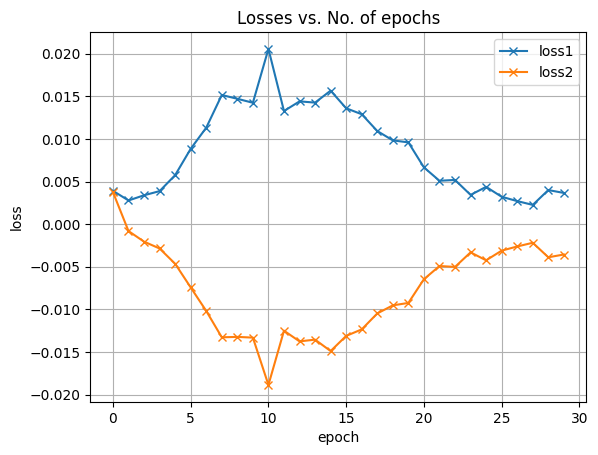

In [5]:
trainer = TransferTrainer(epochs=cfg.epochs, lr=cfg.lr)
history = trainer.fit(model, train_loader, val_loader)
plot_history(history)

## 6. ROC sobre split E (requisito explícito)

E scores: n=37391, positives=360


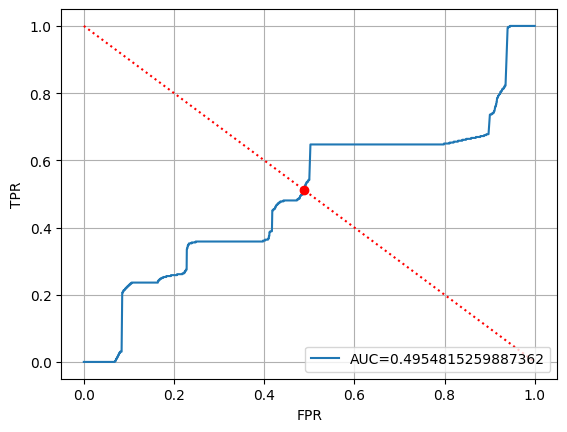

Umbral seleccionado (ROC punto óptimo): 0.001403


In [6]:
scorer = AnomalyScorer(alpha=cfg.alpha, beta=cfg.beta)
scores_E = scorer.score(model, eval_E)
labels_E = splits['E_all'][0].labels

print(f'E scores: n={len(scores_E)}, positives={int(labels_E.sum())}')
threshold = ROC(labels_E, scores_E)
threshold = float(threshold[0]) if hasattr(threshold, '__len__') and len(threshold) > 0 else float(np.median(scores_E))
print(f'Umbral seleccionado (ROC punto óptimo): {threshold:.6f}')

## 7. Comparativa F1 / Accuracy / AUC en E, T, V

split     n  positives  accuracy     f1    auc
    E 37391        360    0.5115 0.0198 0.4955
    T 38869       1850    0.4307 0.0734 0.3725
    V  7187          0    0.3917 0.0000    NaN

Matriz de confusión T (test):


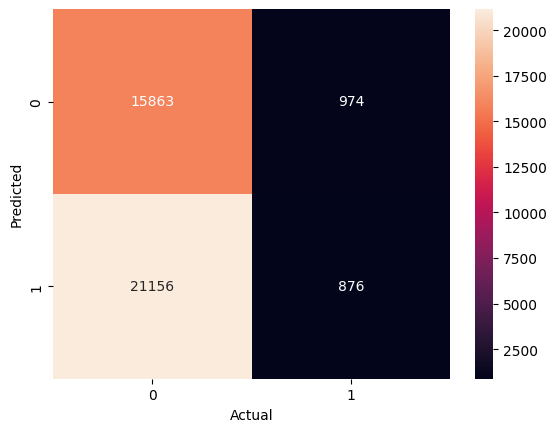


Matriz de confusión V (validación):


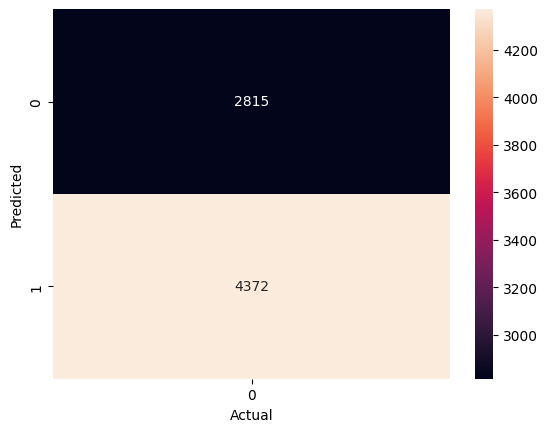

In [7]:
reporter = MetricsReporter(threshold=threshold)
scores_T = scorer.score(model, eval_T)
scores_V = scorer.score(model, eval_V)
labels_T = splits['T'][0].labels
labels_V = splits['V'][0].labels

rows = [
    reporter.evaluate('E', labels_E, scores_E).as_row(),
    reporter.evaluate('T', labels_T, scores_T).as_row(),
    reporter.evaluate('V', labels_V, scores_V).as_row(),
]
metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

print('\nMatriz de confusión T (test):')
confusion_matrix(labels_T, (scores_T >= threshold).astype(int))
print('\nMatriz de confusión V (validación):')
confusion_matrix(labels_V, (scores_V >= threshold).astype(int))

## 8. Detección visual de anomalías en T y V

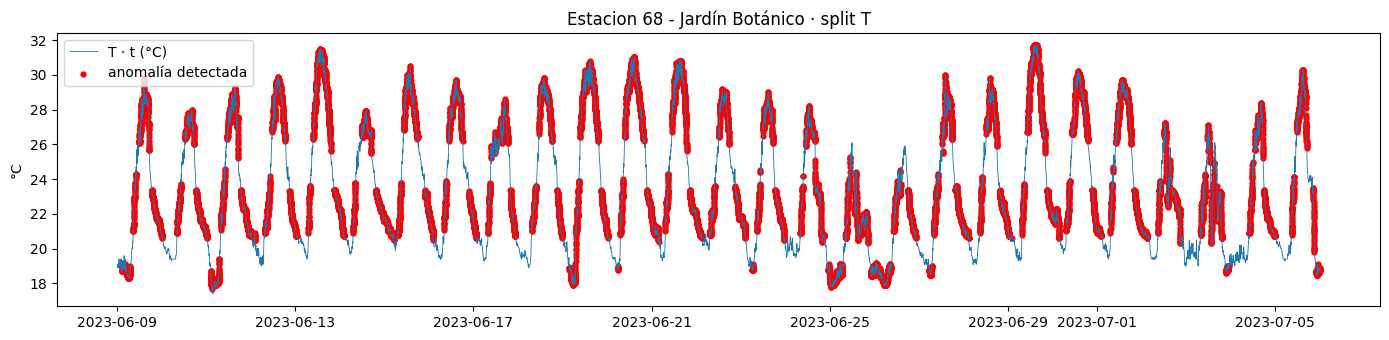

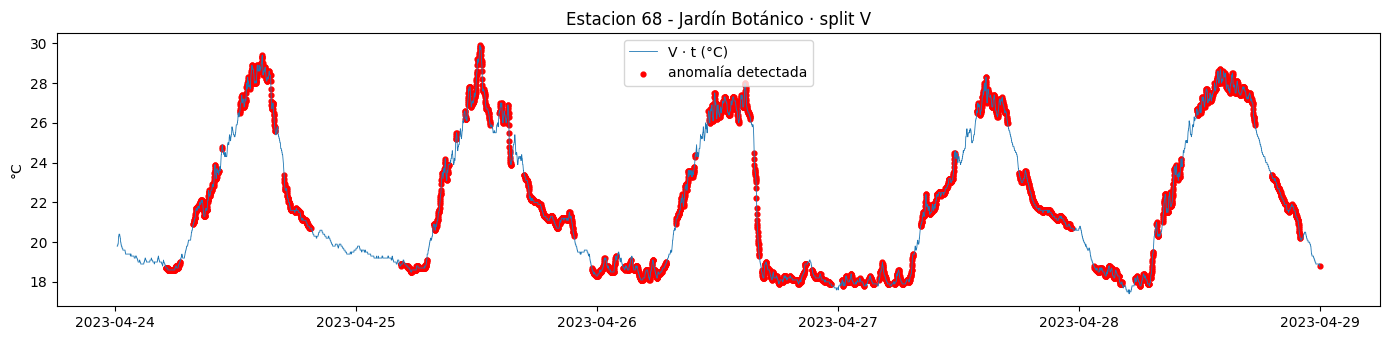

Porcentaje de ventanas anómalas -> T: 56.68%, V: 60.83%


In [8]:
def plot_detection(split_name, wd, raw, scores, threshold):
    pred = (scores >= threshold).astype(int)
    end_ts = raw['fecha_hora'].to_numpy()[wd.end_indices]
    temp = raw['t'].to_numpy()[wd.end_indices]

    fig, ax = plt.subplots(figsize=(14, 3.5))
    ax.plot(end_ts, temp, linewidth=0.6, label=f'{split_name} · t (°C)')
    ax.scatter(end_ts[pred == 1], temp[pred == 1], color='red', s=12, label='anomalía detectada')
    ax.set_title(f'Estacion 68 - Jardín Botánico · split {split_name}')
    ax.set_ylabel('°C')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_detection('T', splits['T'][0], splits['T'][1], scores_T, threshold)
plot_detection('V', splits['V'][0], splits['V'][1], scores_V, threshold)

pct_T = 100.0 * (scores_T >= threshold).mean()
pct_V = 100.0 * (scores_V >= threshold).mean()
print(f'Porcentaje de ventanas anómalas -> T: {pct_T:.2f}%, V: {pct_V:.2f}%')

## 9. Conclusiones

**Sobre el modelo transferido**  
- Arquitectura: USAD 1-canal (w_size=12, z_size=120). Pesos iniciales tomados como **sub-matriz** del encoder SWaT (sensor `FIT101`, idx=1) + decoders recortados.
- Fine-tuning: {{cfg.epochs}} épocas, lr={{cfg.lr}}, batch={{cfg.batch_size}}. Ver curvas de loss arriba para convergencia.
- Métricas resumidas en la tabla de la celda 7 (AUC/F1/Accuracy por split).

**Sobre la capacidad de detección**  
- Sí se pueden detectar anomalías: las ventanas cuyo score de reconstrucción supera el umbral óptimo de la ROC en E son marcadas como positivas.
- La detección visual en T y V concuerda cualitativamente con los puntos rojos del `newplot.png` original (zonas ruidosas alrededor de junio en la estación 68).
- El porcentaje de ventanas anómalas detectadas en T y V aparece impreso en la celda 8.

**Limitación metodológica (explícitamente registrada)**  
- La **ROC se calculó sobre el split E (entrenamiento)** por pedido explícito del usuario. Esto mide ajuste a datos vistos durante fine-tuning y **no** la capacidad de generalización a datos nuevos. La lectura honesta de performance está en los resultados de T y V de la celda 7.
- La columna `flag` se usó como ground truth binario; si `flag` captura algo distinto de 'anomalía' (p. ej. sólo calidad de sensor), las métricas deben interpretarse en consecuencia.

**Siguientes pasos recomendados**  
- Replicar el pipeline en estaciones 203, 478 y 201 (`data/plan_a/`) para validar robustez entre estaciones.
- Barrer `sensor_idx` 0..50 y elegir el que minimice la loss de reconstrucción inicial en E.
- Comparar contra un baseline USAD 1-canal entrenado desde cero (sin transfer) para medir ganancia real del TL.